### Estudo da variabilidade das respostas dos modelos OpenSource SLR1

Vamos simular as variabilidade das respostas dos lhamas, olhando os resultados processados diversas vezes para cada modelo.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from together import Together
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [ ]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

In [ ]:
for key in os.environ.keys():
    print(f'{key}')

In [ ]:
client = Together(api_key = os.getenv('TOGETHER_API_KEY_LLMS'))

# Together para usar os lhamas
-----

### Leitura dos arquivos

In [ ]:
df_slr1 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr1_v2.xlsx",engine='openpyxl')
df_slr1.head()

In [ ]:
df_slr1 = df_slr1.replace({r'_x000D_|\n': ''}, regex=True)

In [ ]:
df_slr1.head()

#### Limpeza dos casos em que não conseguimos extrair as informações


In [ ]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr1['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

In [ ]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr1['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

In [ ]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr1_clear = df_slr1.loc[((df_slr1['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr1['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr1_clear.shape

In [ ]:
print(df_slr1_clear["sucesso_fracasso_resumo"].value_counts())
print(df_slr1_clear["sucesso_fracasso_palavras"].value_counts())

In [ ]:
print("Shape antes da limpeza: "+str(df_slr1.shape))
print("Shape depois da limpeza"+str(df_slr1_clear.shape))

In [ ]:
# Renomear as colunas do dataframe df_slr1_clear
df_slr1_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr1_clear.head(2)

### Seleção usando o model_together

In [48]:
def process_selection_with_together(model_together, title, abstract, keywords,inclusion_criteria_question,client):
    """
    realiza a seleção dos artigos usando a escala likert, conforme o artigo original
    """
    
    # Contexto final para responder as perguntas
    system_message = {
        "role": "system", 
        "content": """Assume you are a software engineering researcher. 
        Conducting a systematic literature review (SLR). Consider the title, abstract and keywords of a primary study"""
    }

    # Prompt final com as perguntas

    # Prompt final com as perguntas, aprimorado para o último bloco
    user_message = { "role": "user",
                     "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Abstract: {abstract}\n Keywords: {keywords} \n
                    Respond with only the number, with no other text or explanation."""
                    }

   
    # Criação da chamada para a API
    response = client.chat.completions.create(
        model="meta-llama/"+model_together,
        messages=[system_message, user_message],
        temperature=0,
        max_tokens=1,
        top_p=0.1
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))

    return resposta

In [ ]:
model_together = "Llama-3.2-3B-Instruct-Turbo"
title1 = df_slr1_clear['title'].iloc[34]
abstract1 =  df_slr1_clear['abstract'].iloc[34]
keywords1 = df_slr1_clear['keywords'].iloc[34]
inclusion_criteria_question1 =  """The article discusses the relationship between game
 elements and user types."""

process_selection_with_together(model_together = model_together,
                          title = title1,
                          abstract = abstract1,
                          keywords=keywords1,
                          inclusion_criteria_question = inclusion_criteria_question1,
                          client=client)


In [40]:
def repeat_selection_with_together(df, model_together, inclusion_criteria_question, client,n_interactions,name_ic):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        print(i)
        coluna_aux = model_together+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr1_{model_together}_{name_ic}_iter_{i}_v2.xlsx"
        df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_together(model_together,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(60)  # pausa de 20 segundos entre as interações
    return df

#### Modelo: "meta-llama/Llama-3.2-3B-Instruct-Turbo"

In [ ]:
df_gpt_4o  = df_slr1_clear.copy()
df_gpt_4o.head(2)

In [ ]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.2-3B-Instruct-Turbo" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_4o = repeat_selection_with_together(df = df_gpt_4o,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

In [ ]:
df_gpt_4o.head(2)

In [ ]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.2-3B-Instruct-Turbo" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_4o = repeat_selection_with_together(df = df_gpt_4o,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

In [ ]:
df_gpt_4o.head()

#### Modelo "meta-llama/Llama-3.3-70B-Instruct-Turbo-Free"

In [36]:
df_gpt_3_5  = df_slr1_clear.copy()
df_gpt_3_5.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [37]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [38]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """TIt is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_3_5 = repeat_selection_with_together(df = df_gpt_3_5,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [16:54<00:00,  8.05s/it]


1


100%|██████████| 126/126 [17:03<00:00,  8.12s/it]


2


100%|██████████| 126/126 [18:19<00:00,  8.73s/it]


3


100%|██████████| 126/126 [17:10<00:00,  8.18s/it]


4


100%|██████████| 126/126 [16:22<00:00,  7.80s/it]


In [41]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_3_5 = repeat_selection_with_together(df = df_gpt_3_5,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [17:22<00:00,  8.28s/it]


1


100%|██████████| 126/126 [17:14<00:00,  8.21s/it]


2


100%|██████████| 126/126 [17:05<00:00,  8.14s/it]


3


100%|██████████| 126/126 [17:46<00:00,  8.46s/it]


4


100%|██████████| 126/126 [17:47<00:00,  8.47s/it]


### Modelo "meta-llama/Llama-4-Scout-17B-16E-Instruct"

In [49]:
df_gpt_4_1  = df_slr1_clear.copy()
df_gpt_4_1.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado


In [50]:
df_gpt_4_1.iloc[34, ]

ID                                                                     slr1_37
title                        Speech Difficulties  and Clarification: A Syst...
abstract                     Natural language processing helps the computer...
keywords                      Machine Learning, Speech Clarification,De-noi...
sucesso_fracasso_resumo                                                sucesso
sucesso_fracasso_palavras                                              sucesso
segunda_coleta                                                             não
obs                                                            não estruturado
Name: 36, dtype: object

In [51]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [52]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-4-Scout-17B-16E-Instruct" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_4_1 = repeat_selection_with_together(df = df_gpt_4_1,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:32<00:00,  1.37it/s]


1


100%|██████████| 126/126 [06:52<00:00,  3.27s/it]


2


100%|██████████| 126/126 [08:52<00:00,  4.23s/it]


3


100%|██████████| 126/126 [02:41<00:00,  1.28s/it]


4


100%|██████████| 126/126 [02:18<00:00,  1.10s/it]


In [53]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-4-Scout-17B-16E-Instruct" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_4_1 = repeat_selection_with_together(df = df_gpt_4_1,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 126/126 [01:55<00:00,  1.09it/s]


1


100%|██████████| 126/126 [02:08<00:00,  1.02s/it]


2


100%|██████████| 126/126 [02:18<00:00,  1.10s/it]


3


100%|██████████| 126/126 [02:05<00:00,  1.00it/s]


4


100%|██████████| 126/126 [02:27<00:00,  1.17s/it]


### Gravação

#### Llama-3.3-70B-Instruct-Turbo-Free

In [42]:
df_gpt_3_5.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-3.3-70B-Instruct-Turbo-Free_IC1_0,Llama-3.3-70B-Instruct-Turbo-Free_IC1_1,Llama-3.3-70B-Instruct-Turbo-Free_IC1_2,Llama-3.3-70B-Instruct-Turbo-Free_IC1_3,Llama-3.3-70B-Instruct-Turbo-Free_IC1_4,Llama-3.3-70B-Instruct-Turbo-Free_IC2_0,Llama-3.3-70B-Instruct-Turbo-Free_IC2_1,Llama-3.3-70B-Instruct-Turbo-Free_IC2_2,Llama-3.3-70B-Instruct-Turbo-Free_IC2_3,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,5,5,5,5,2,2,2,2,2


In [43]:
# grava os resultados
df_gpt_3_5.to_excel("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr1_v2.xlsx", index=False)
df_gpt_3_5.to_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr1_v2.csv", encoding='utf-8', index=False)

#### Llama-3.2-3B-Instruct-Turbo"

In [54]:
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-3.2-3B-Instruct-Turbo_IC1_0,Llama-3.2-3B-Instruct-Turbo_IC1_1,Llama-3.2-3B-Instruct-Turbo_IC1_2,Llama-3.2-3B-Instruct-Turbo_IC1_3,Llama-3.2-3B-Instruct-Turbo_IC1_4,Llama-3.2-3B-Instruct-Turbo_IC2_0,Llama-3.2-3B-Instruct-Turbo_IC2_1,Llama-3.2-3B-Instruct-Turbo_IC2_2,Llama-3.2-3B-Instruct-Turbo_IC2_3,Llama-3.2-3B-Instruct-Turbo_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,4,4,4,4,4
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,4,4,4,4,4


In [55]:
# grava os resultados
df_gpt_4o.to_excel("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo_slr1_v2.xlsx", index=False)
df_gpt_4o.to_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo _slr1_v2.csv", encoding='utf-8', index=False)

#### Llama-4-Scout-17B-16E-Instruct

In [56]:
df_gpt_4_1.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,2,2,2,2,2


In [57]:
# grava os resultados
df_gpt_4_1.to_excel("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr1_v2.xlsx", index=False)
df_gpt_4_1.to_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr1_v2.csv", encoding='utf-8', index=False)

## Analise dos resultados

### Leitura dos resultados processados

In [58]:
df_gpt3 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr1_v2.csv",encoding='utf-8')
df_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-3.3-70B-Instruct-Turbo-Free_IC1_0,Llama-3.3-70B-Instruct-Turbo-Free_IC1_1,Llama-3.3-70B-Instruct-Turbo-Free_IC1_2,Llama-3.3-70B-Instruct-Turbo-Free_IC1_3,Llama-3.3-70B-Instruct-Turbo-Free_IC1_4,Llama-3.3-70B-Instruct-Turbo-Free_IC2_0,Llama-3.3-70B-Instruct-Turbo-Free_IC2_1,Llama-3.3-70B-Instruct-Turbo-Free_IC2_2,Llama-3.3-70B-Instruct-Turbo-Free_IC2_3,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,5,5,5,5,2,2,2,2,2


In [59]:
df_gpt4 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo _slr1_v2.csv",encoding='utf-8')
df_gpt4.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-3.2-3B-Instruct-Turbo_IC1_0,Llama-3.2-3B-Instruct-Turbo_IC1_1,Llama-3.2-3B-Instruct-Turbo_IC1_2,Llama-3.2-3B-Instruct-Turbo_IC1_3,Llama-3.2-3B-Instruct-Turbo_IC1_4,Llama-3.2-3B-Instruct-Turbo_IC2_0,Llama-3.2-3B-Instruct-Turbo_IC2_1,Llama-3.2-3B-Instruct-Turbo_IC2_2,Llama-3.2-3B-Instruct-Turbo_IC2_3,Llama-3.2-3B-Instruct-Turbo_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,4,4,4,4,4
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,4,4,4,4,4,4,4,4,4,4


In [60]:
df_gpt41 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr1_v2.csv",encoding='utf-8')
df_gpt41.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,6,6,6,6,6
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,7,7,7,7,7,2,2,2,2,2


In [61]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr1_autores = pd.read_excel("/data/codigos/dados/SLR1-results-keys.xlsx",engine='openpyxl')
df_slr1_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr1_1,User Experience_x000D_\n Design Using Machine...,7.0,6.0,I,1.321527,955.0
1,slr1_2,Sentiment analysis_x000D_\n on arabic tweets:...,7.0,4.0,E,0.922849,707.0
2,slr1_3,Machine learning_x000D_\n based cognitive ski...,7.0,6.0,E,1.285468,705.0
3,slr1_4,Human Factors_x000D_\n Engineering in Interac...,7.0,4.0,E,1.144713,783.0
4,slr1_5,Empirical comparisons_x000D_\n for combining ...,1.0,4.0,E,1.152106,1327.0


In [62]:
df_gpt3 = pd.merge(left=df_gpt3, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt3.shape


(126, 21)

In [63]:
df_gpt4 = pd.merge(left=df_gpt4, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt4.shape

(126, 21)

In [64]:
df_gpt41 = pd.merge(left=df_gpt41, right=df_slr1_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt41.shape

(126, 21)

In [65]:
print("df_gpt3: "+str(df_gpt3.shape))
print("df_gpt4: "+str(df_gpt4.shape))
print("df_gpt41: "+str(df_gpt41.shape))
print("df_slr1_autores: "+str(df_slr1_autores.shape))


df_gpt3: (126, 21)
df_gpt4: (126, 21)
df_gpt41: (126, 21)
df_slr1_autores: (135, 7)


### Geração dos resultados das llms e padronizacao dos campos

In [66]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [67]:
df_gpt3 = convert_benchmark(df_gpt3,"Benchmark")

In [68]:
df_gpt4 = convert_benchmark(df_gpt4,"Benchmark")

In [69]:
df_gpt41 = convert_benchmark(df_gpt41,"Benchmark")

In [70]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [71]:
df_gpt3.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-3.3-70B-Instruct-Turbo-Free_IC1_0,Llama-3.3-70B-Instruct-Turbo-Free_IC1_1,...,Llama-3.3-70B-Instruct-Turbo-Free_IC1_4,Llama-3.3-70B-Instruct-Turbo-Free_IC2_0,Llama-3.3-70B-Instruct-Turbo-Free_IC2_1,Llama-3.3-70B-Instruct-Turbo-Free_IC2_2,Llama-3.3-70B-Instruct-Turbo-Free_IC2_3,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,...,7,6,6,6,6,6,7.0,6.0,I,1


In [72]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [73]:
n_interactions = 5
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free"
df_gpt3 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt3)

In [74]:
df_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,Llama-3.3-70B-Instruct-Turbo-Free_IC1_0,Llama-3.3-70B-Instruct-Turbo-Free_IC1_1,...,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4,IC1,IC2,Benchmark,result_bench,Llama-3.3-70B-Instruct-Turbo-Free_0,Llama-3.3-70B-Instruct-Turbo-Free_1,Llama-3.3-70B-Instruct-Turbo-Free_2,Llama-3.3-70B-Instruct-Turbo-Free_3,Llama-3.3-70B-Instruct-Turbo-Free_4
0,slr1_1,User Experience Design Using Machine Learning:...,ser experience (UX) is the key to increased pr...,"User experience, experience design, UX, ED, ma...",sucesso,sucesso,não,não estruturado,7,7,...,6,7.0,6.0,I,1,1,1,1,1,1
1,slr1_2,Sentiment analysis on arabic tweets: Challeng...,Sentiment analysis and opinion mining are desi...,"Twitter, Sentiment analysis, Opinion mining, N...",sucesso,sucesso,não,não estruturado,5,5,...,2,7.0,4.0,E,0,0,0,0,0,0


In [75]:
n_interactions = 5
model_gpt = "Llama-3.2-3B-Instruct-Turbo"
df_gpt4 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt4)

In [76]:
n_interactions = 5
model_gpt = "Llama-4-Scout-17B-16E-Instruct"
df_gpt41 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt41)

### Analises de performance

In [77]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [78]:
n_interactions = 5
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free"
df_result_gpt3 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt3, 
                                    col_benchmark='result_bench')
df_result_gpt3

,Model_Iteration,Accuracy
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.753968
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.753968
2,Llama-3.3-70B-Instruct-Turbo-Free_2,0.753968
3,Llama-3.3-70B-Instruct-Turbo-Free_3,0.753968
4,Llama-3.3-70B-Instruct-Turbo-Free_4,0.753968


In [79]:
n_interactions = 5
model_gpt = "Llama-3.2-3B-Instruct-Turbo"
df_result_gpt4 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt4, 
                                    col_benchmark='result_bench')
df_result_gpt4

,Model_Iteration,Accuracy
0,Llama-3.2-3B-Instruct-Turbo_0,0.611111
1,Llama-3.2-3B-Instruct-Turbo_1,0.611111
2,Llama-3.2-3B-Instruct-Turbo_2,0.611111
3,Llama-3.2-3B-Instruct-Turbo_3,0.611111
4,Llama-3.2-3B-Instruct-Turbo_4,0.611111


In [80]:
n_interactions = 5
model_gpt = "Llama-4-Scout-17B-16E-Instruct"
df_result_gpt41 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt41, 
                                    col_benchmark='result_bench')
df_result_gpt41

,Model_Iteration,Accuracy
0,Llama-4-Scout-17B-16E-Instruct_0,0.801587
1,Llama-4-Scout-17B-16E-Instruct_1,0.801587
2,Llama-4-Scout-17B-16E-Instruct_2,0.801587
3,Llama-4-Scout-17B-16E-Instruct_3,0.801587
4,Llama-4-Scout-17B-16E-Instruct_4,0.809524


In [81]:
def graph_scatter_plot(df,col_values,col_name_models,title_graph,xlabel,ylabel,ylim_flag,ylim):
    # Supondo que df seja o dataframe com as colunas "Model_Iteration" e "Accuracy"
    # Calcular a média e o desvio padrão da acurácia
    mean_accuracy = df[col_values].mean()
    std_accuracy = df[col_values].std()

    # Configurar o tamanho da figura
    plt.figure(figsize=(12, 6))

    # Criar o scatterplot
    plt.scatter(df[col_name_models], df[col_values], color='royalblue', label='Accuracy')

    # Adicionar linhas horizontais para a média e os limites inferior e superior
    plt.axhline(y=mean_accuracy, color='darkblue', linestyle='-', label='Mean Accuracy')
    plt.axhline(y=mean_accuracy - std_accuracy, color='cornflowerblue', linestyle='--', label='Mean - Std Dev')
    plt.axhline(y=mean_accuracy + std_accuracy, color='cornflowerblue', linestyle='--', label='Mean + Std Dev')

    # Adicionar título e nomes nos eixos
    plt.title(title_graph)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Adicionar legenda
    plt.legend()

    # limite
    if ylim_flag:
        plt.ylim(ylim)

    # Rotacionar os rótulos do eixo x para melhor visualização
    plt.xticks(rotation=45)

    # Exibir o gráfico
    plt.tight_layout()
    
    # Remover bordas desnecessárias
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()



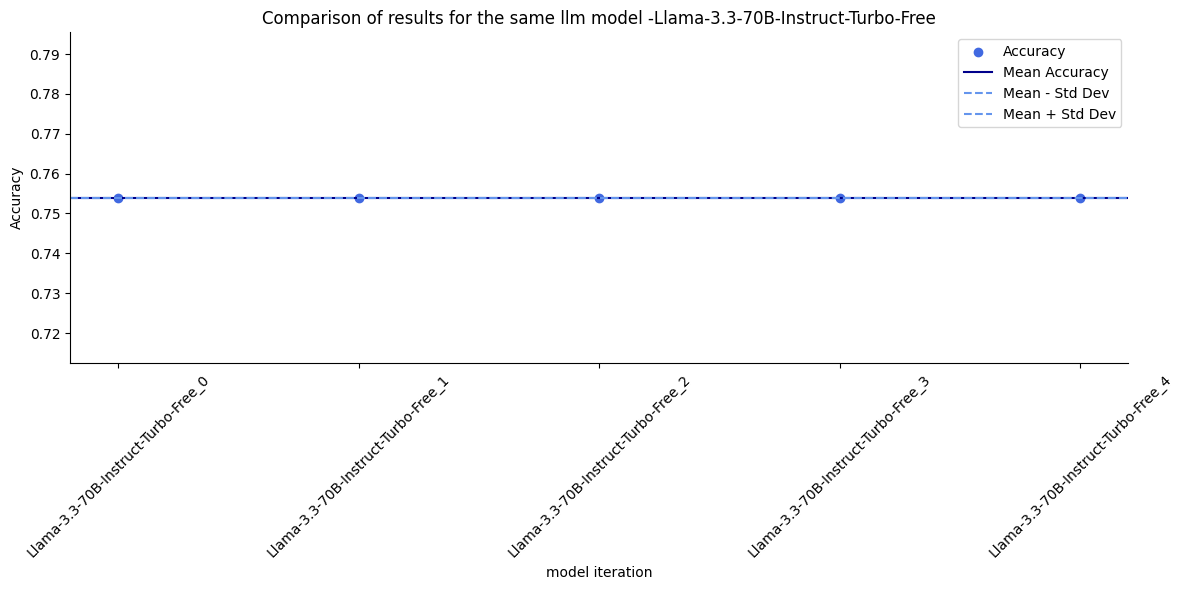

In [82]:
graph_scatter_plot(df = df_result_gpt3,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model -Llama-3.3-70B-Instruct-Turbo-Free",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

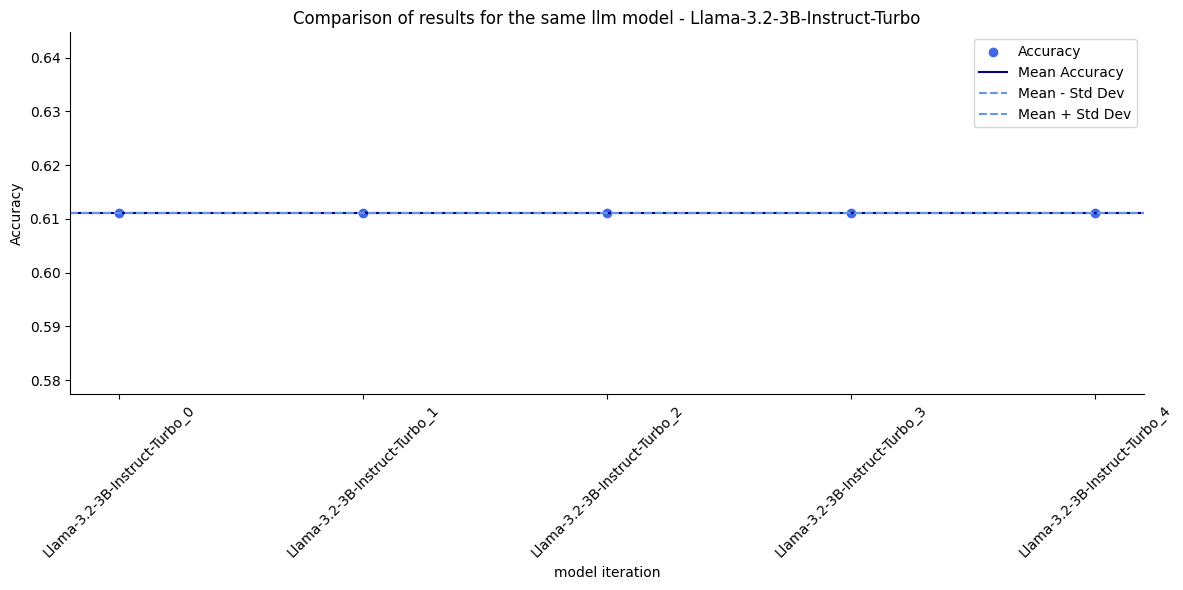

In [83]:
graph_scatter_plot(df = df_result_gpt4,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - Llama-3.2-3B-Instruct-Turbo",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

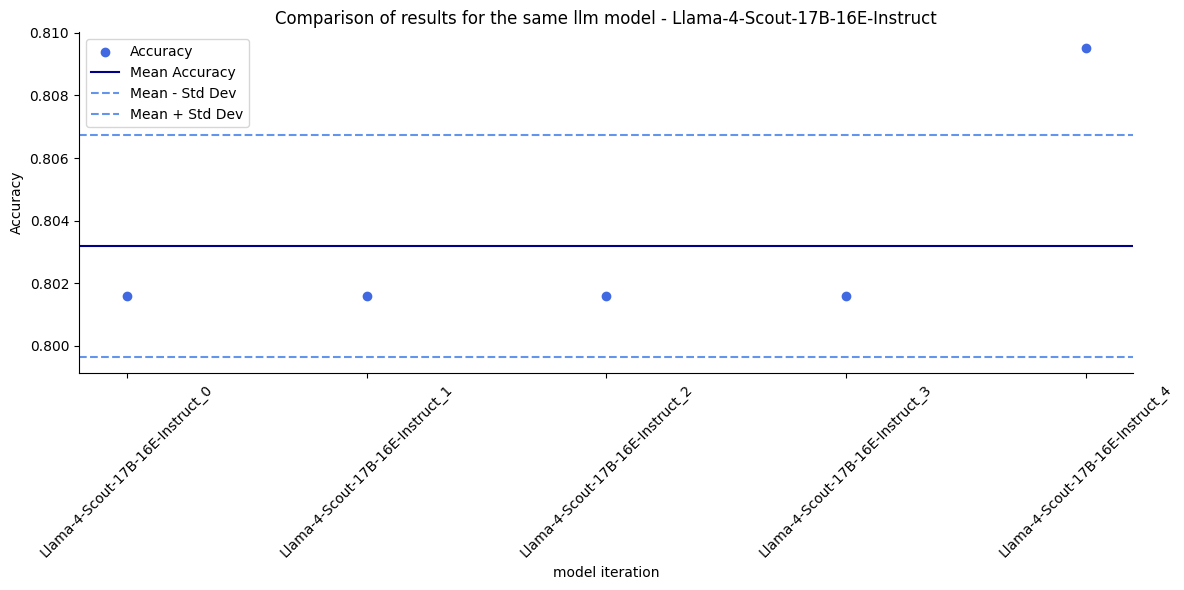

In [84]:
graph_scatter_plot(df = df_result_gpt41,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - Llama-4-Scout-17B-16E-Instruct",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.9])

Nota-se que para modelos mais avançados a variabilidade é menor, indicando estabilização mais rápida.

In [85]:
### Grava os resultados finais
df_result_gpt3.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.3-70B-Instruct-Turbo-Free_final_srl1_v2.xlsx", index=False)
df_result_gpt3.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.3-70B-Instruct-Turbo-Free_final_srl1_v2.csv", encoding='utf-8', index=False)

df_result_gpt4.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.2-3B-Instruct-Turbo_final_srl1_v2.xlsx", index=False)
df_result_gpt4.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.2-3B-Instruct-Turbo_final_srl1_v2.csv", encoding='utf-8', index=False)

df_result_gpt41.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_Llama-4-Scout-17B-16E-Instruct_final_srl1_v2.xlsx", index=False)
df_result_gpt41.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_Llama-4-Scout-17B-16E-Instruct_final_srl1_v2.csv", encoding='utf-8', index=False)

### Comparativo geral

In [87]:
df_result_gpt3.head(2)

,Model_Iteration,Accuracy
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.753968
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.753968


In [88]:
df_result_gpt3["iteration"] = df_result_gpt3["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt3["model"] = "Llama-3.3-70B-Instruct-Turbo-Free"
df_result_gpt3

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.753968,0,Llama-3.3-70B-Instruct-Turbo-Free
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.753968,1,Llama-3.3-70B-Instruct-Turbo-Free
2,Llama-3.3-70B-Instruct-Turbo-Free_2,0.753968,2,Llama-3.3-70B-Instruct-Turbo-Free
3,Llama-3.3-70B-Instruct-Turbo-Free_3,0.753968,3,Llama-3.3-70B-Instruct-Turbo-Free
4,Llama-3.3-70B-Instruct-Turbo-Free_4,0.753968,4,Llama-3.3-70B-Instruct-Turbo-Free


In [89]:
df_result_gpt4["iteration"] = df_result_gpt4["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt4["model"] = "Llama-3.2-3B-Instruct-Turbo"
df_result_gpt4

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.2-3B-Instruct-Turbo_0,0.611111,0,Llama-3.2-3B-Instruct-Turbo
1,Llama-3.2-3B-Instruct-Turbo_1,0.611111,1,Llama-3.2-3B-Instruct-Turbo
2,Llama-3.2-3B-Instruct-Turbo_2,0.611111,2,Llama-3.2-3B-Instruct-Turbo
3,Llama-3.2-3B-Instruct-Turbo_3,0.611111,3,Llama-3.2-3B-Instruct-Turbo
4,Llama-3.2-3B-Instruct-Turbo_4,0.611111,4,Llama-3.2-3B-Instruct-Turbo


In [90]:
df_result_gpt41["iteration"] = df_result_gpt41["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt41["model"] = "Llama-4-Scout-17B-16E-Instruct"
df_result_gpt41

,Model_Iteration,Accuracy,iteration,model
0,Llama-4-Scout-17B-16E-Instruct_0,0.801587,0,Llama-4-Scout-17B-16E-Instruct
1,Llama-4-Scout-17B-16E-Instruct_1,0.801587,1,Llama-4-Scout-17B-16E-Instruct
2,Llama-4-Scout-17B-16E-Instruct_2,0.801587,2,Llama-4-Scout-17B-16E-Instruct
3,Llama-4-Scout-17B-16E-Instruct_3,0.801587,3,Llama-4-Scout-17B-16E-Instruct
4,Llama-4-Scout-17B-16E-Instruct_4,0.809524,4,Llama-4-Scout-17B-16E-Instruct


In [91]:
# concatena os dataframes
df_results = pd.concat([df_result_gpt3, df_result_gpt4, df_result_gpt41], ignore_index=True)
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.753968,0,Llama-3.3-70B-Instruct-Turbo-Free
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.753968,1,Llama-3.3-70B-Instruct-Turbo-Free


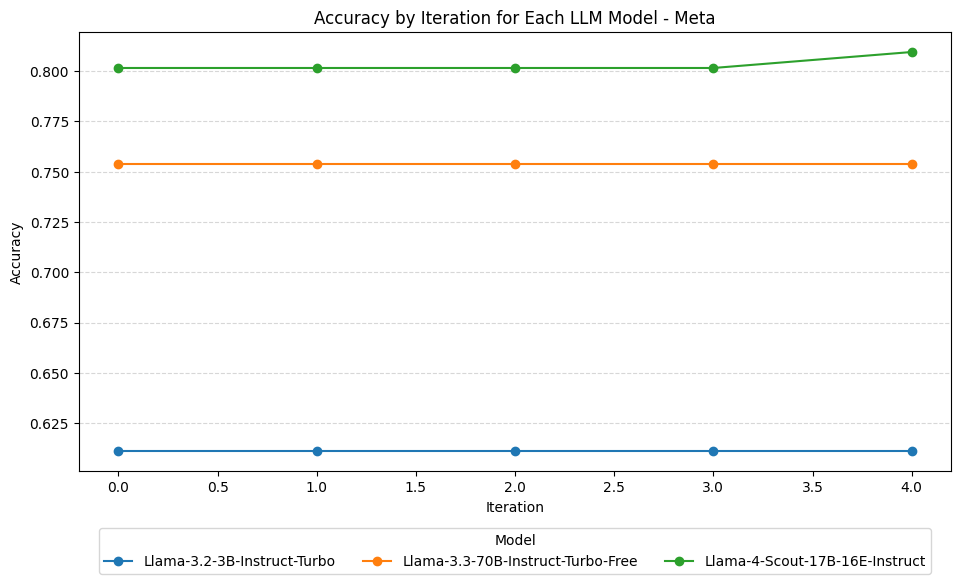

In [92]:
plt.figure(figsize=(10, 6))

for model_name, group in df_results.groupby("model"):
    plt.plot(group["iteration"], group["Accuracy"], marker='o', label=model_name)

plt.title("Accuracy by Iteration for Each LLM Model - Meta")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend(title="Model", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [93]:
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.753968,0,Llama-3.3-70B-Instruct-Turbo-Free
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.753968,1,Llama-3.3-70B-Instruct-Turbo-Free


In [94]:
summary_stats = df_results.groupby('model')['Accuracy'].agg(['mean', 'std'])
summary_stats

,mean,std
model,,
Llama-3.2-3B-Instruct-Turbo,0.611111,0.000000
Llama-3.3-70B-Instruct-Turbo-Free,0.753968,0.000000
Llama-4-Scout-17B-16E-Instruct,0.803175,0.003549


In [95]:
summary_stats["model"] = summary_stats.index
summary_stats = summary_stats.reset_index(drop=True)
summary_stats["ic_lower"] = summary_stats["mean"] - summary_stats["std"]
summary_stats["ic_upper"] = summary_stats["mean"] + summary_stats["std"]
summary_stats

,mean,std,model,ic_lower,ic_upper
0,0.611111,0.000000,Llama-3.2-3B-Instruct-Turbo,0.611111,0.611111
1,0.753968,0.000000,Llama-3.3-70B-Instruct-Turbo-Free,0.753968,0.753968
2,0.803175,0.003549,Llama-4-Scout-17B-16E-Instruct,0.799625,0.806724
